## Solución del problema mediante algoritmo de DPLL 
A continuación intentaremos encontrar un modelo para las reglas utilizando el algoritmo de DPLL

In [1]:
from logica import*   
from grafos import*

In [ ]:
g=Grafos()

In [118]:
'''def filtro(dict_tseitin, regla): 
    h = inorder_to_tree(regla) 
    letras = h.letras()  
    #Hacemos u ncopy para que el recorrido sea estable
    for letter in dict_tseitin.copy(): 
        if letter not in letras: 
            del dict_tseitin[letter] 
    return dict_tseitin'''

def filtro(dict_tseitin, regla): 
    h = inorder_to_tree(regla) 
    letras = h.letras()

    # 🔹 solo nos quedamos con variables reales (las de To)
    letras_validas = set()
    for l in letras:
        # 🔥 condición: solo variables originales (no auxiliares unicode)
        if ord(l) < 1000:   # mismo umbral que usamos antes
            letras_validas.add(l)

    for letter in dict_tseitin.copy(): 
        if letter not in letras_validas: 
            del dict_tseitin[letter] 

    return dict_tseitin 

In [119]:
%time 
#REGLA 1
A1 = g.reglas[0]
ts1 = tseitin(A1)   
r1 = dpll(ts1, {}) 
I1 = filtro(r1[1], A1)


CPU times: total: 0 ns
Wall time: 6.91 μs


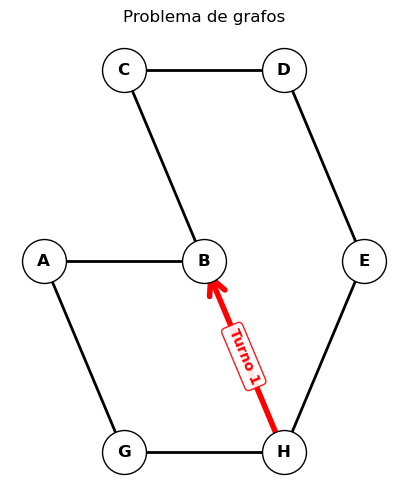

In [120]:
g.visualizar_grafo(I1)

In [121]:
%time  
#REGLA 2
A2 = g.reglas[1] 
ts2 = tseitin(A2)   
r2 = dpll(ts2, {}) 
I2 = filtro(r2[1], A2) 


CPU times: total: 0 ns
Wall time: 8.11 μs


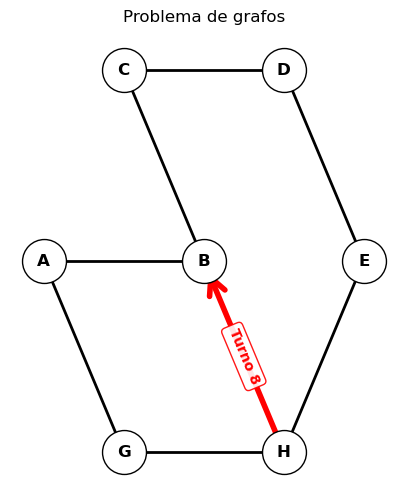

In [122]:
g.visualizar_grafo(I2)

In [123]:
#Regla 3 
%time  
A3 = g.reglas[2] 
ts3 = tseitin(A3)   
r3 = dpll(ts3, {}) 
I3 = filtro(r3[1], A3)  

#REGLA 3 dañada :C


CPU times: total: 0 ns
Wall time: 8.11 μs


KeyboardInterrupt: 

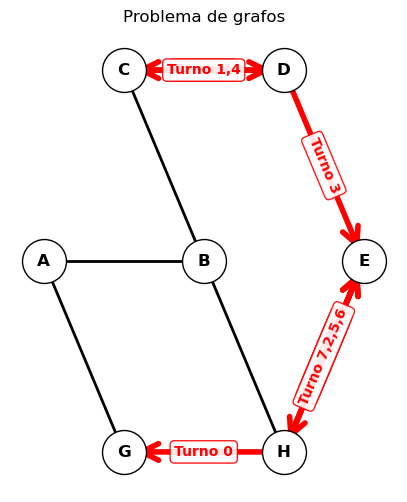

In [86]:
g.visualizar_grafo(I3)

In [93]:
#Regla 4
%time  

A4 = g.reglas[3] 
A4
#ts4 = tseitin(A4)   
#r4 = dpll(ts4, {}) 
#I4 = filtro(r4[1], A4)  

CPU times: total: 0 ns
Wall time: 10 μs


'(((((((((((((((((((((((Ā>((((((-(ĐOđ)Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű)))Y(Đ>((((((-(ĀOā)Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(Ġ>((((((-(ĀOā)Y-(ĐOđ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(İ>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(ŀ>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(Ő>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŠOš))Y-(ŰOű))))Y(Š>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŰOű))))Y(Ű>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))))Y((((((((ā>((((((-(đOĐ)Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ)))Y(đ>((((((-(āOĀ)Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(ġ>((((((-(āOĀ)Y-(đOĐ))Y-(ıOİ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(ı>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(Ł>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ıOİ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(ő>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y-(šOŠ))Y-(űOŰ))))Y(š>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y

regla 4 no corrió después de 236 minutos

In [124]:
def regla4_1():
    formula_lista_aristas = []
    contador_aux = 1000  # unicode seguro

    for (i, j) in g.recorridos:

        # 🔹 variables de la arista (ambas direcciones)
        vars_arista = []
        for t in range(g.turnos):
            vars_arista.append(g.To.ravel([(i, j), t]))
            vars_arista.append(g.To.ravel([(j, i), t]))

        n = len(vars_arista)
        if n <= 1:
            continue

        # 🔹 auxiliares unicode
        s = []
        for _ in range(n - 1):
            s.append(chr(contador_aux))
            contador_aux += 1

        formula_actual = ""
        inicial = True

        # 🔹 (¬x1 ∨ s1)  →  -x1 O s1
        c = "(-" + vars_arista[0] + "O" + s[0] + ")"
        formula_actual = c
        inicial = False

        # 🔹 resto
        for k in range(1, n - 1):
            xk = vars_arista[k]

            c1 = "(-" + xk + "O" + s[k] + ")"
            c2 = "(-" + s[k-1] + "O" + s[k] + ")"
            c3 = "(-" + xk + "O-" + s[k-1] + ")"

            for c in [c1, c2, c3]:
                formula_actual = "(" + formula_actual + "Y" + c + ")"

        # 🔹 última: (¬xn ∨ ¬s_{n-1})
        c_last = "(-" + vars_arista[-1] + "O-" + s[-1] + ")"
        formula_actual = "(" + formula_actual + "Y" + c_last + ")"

        formula_lista_aristas.append(formula_actual)

    # 🔹 unión final tipo cebolla
    formula_final = ""
    inicial_final = True

    for f in formula_lista_aristas:
        if inicial_final:
            formula_final = f
            inicial_final = False
        else:
            formula_final = "(" + formula_final + "Y" + f + ")"

    return formula_final

In [127]:
%time
A4_1 = regla4_1() 
ts4 = tseitin(A4_1)  
r4 = dpll(ts4, {}) 
I4 = filtro(r4[1], A4_1)  

CPU times: total: 0 ns
Wall time: 45.3 μs


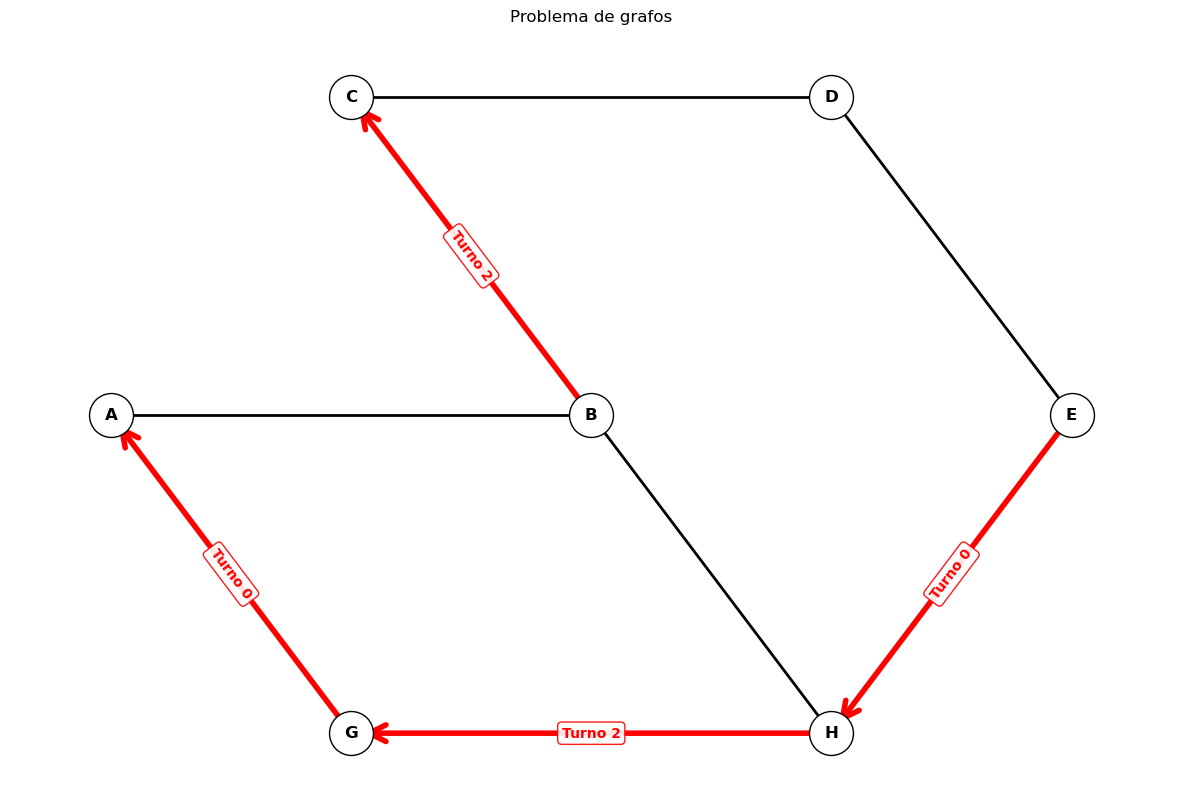

In [126]:
g.visualizar_grafo(I4,custom_size=(15,10) )

In [130]:
def regla5():
    formula_lista = []

    # 🔹 precomputar salidas
    salidas = {}
    for (a,b) in g.recorridos:
        if a not in salidas:
            salidas[a] = []
        salidas[a].append((a,b))

    for t in range(1, g.turnos):
        for (i, j) in g.recorridos:

            salidas_desde_j = salidas.get(j, [])

            # 🔹 construir consecuente más rápido
            if not salidas_desde_j:
                continue

            formula_consecuente = g.To.ravel([salidas_desde_j[0], t])

            for (a,b) in salidas_desde_j[1:]:
                formula_consecuente = "(" + formula_consecuente + "O" + g.To.ravel([(a,b), t]) + ")"

            # 🔹 antecedente
            formula_antecedente = g.To.ravel([(i, j), t - 1])

            # 🔹 implicación
            formula_lista.append("(" + formula_antecedente + ">" + formula_consecuente + ")")

    # 🔹 cebolla final
    if not formula_lista:
        return ""

    formula = formula_lista[0]
    for f in formula_lista[1:]:
        formula = "(" + formula + "Y" + f + ")"

    return formula

In [139]:
%time
A5 = regla5() 
ts5 = tseitin(A5)  
r5 = dpll(ts5, {})  
I = r5[1]
I5 = filtro(r5[1], A5)  

CPU times: total: 0 ns
Wall time: 7.15 μs


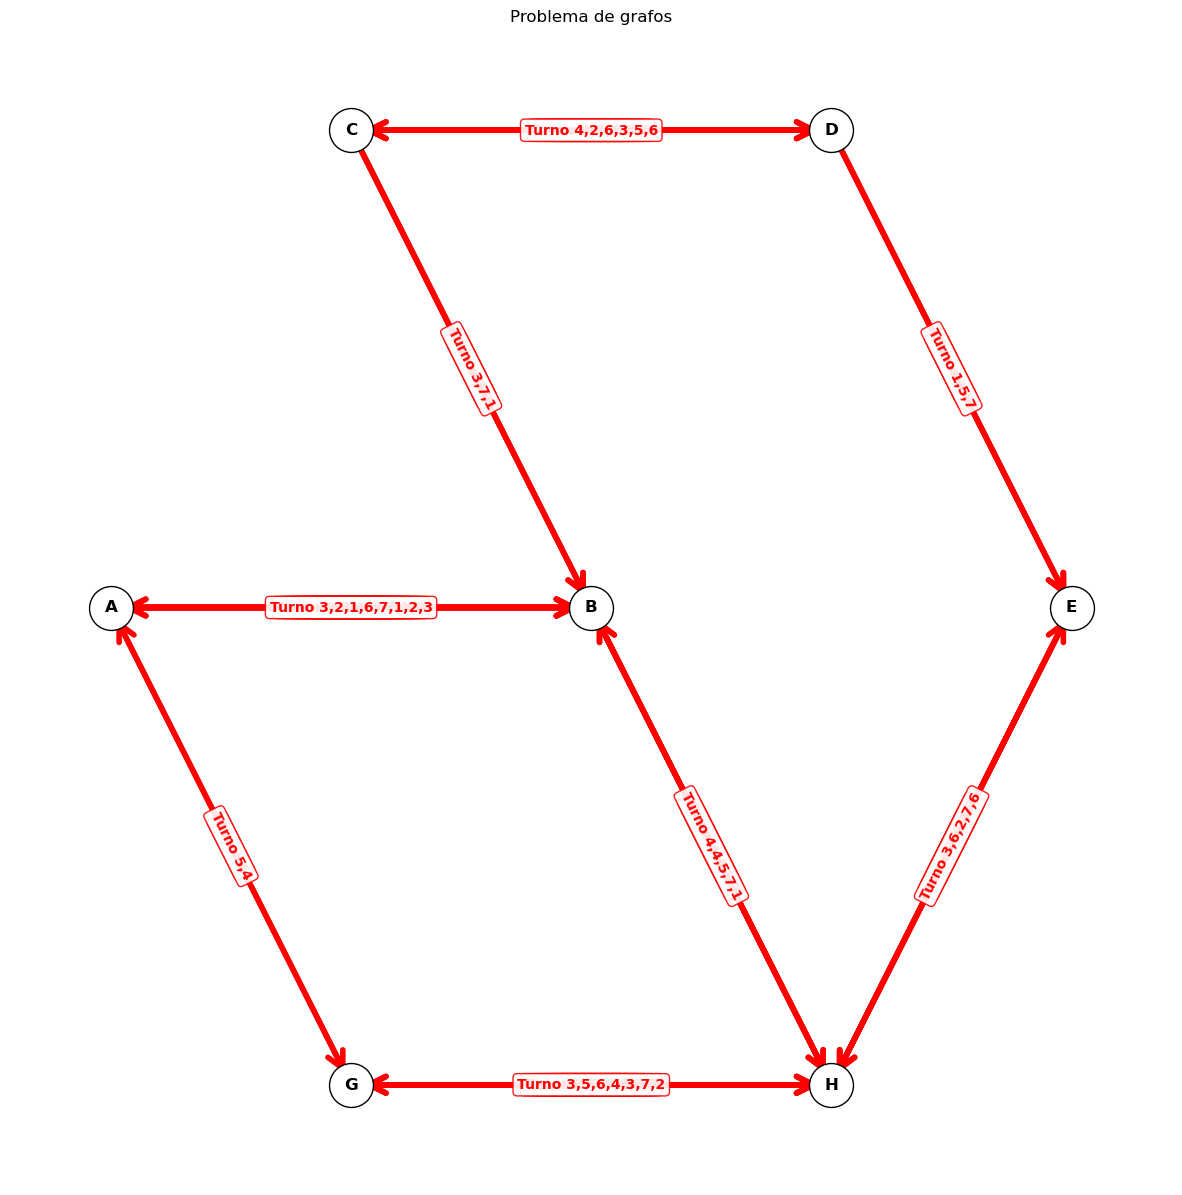

In [133]:
g.visualizar_grafo(I5, custom_size=(15,15))

In [136]:
for t in range(1, g.turnos):
    for (i,j) in g.recorridos:

        if I.get(g.To.ravel([(i,j), t-1]), False):

            ok = False
            for (a,b) in g.recorridos:
                if a == j and I.get(g.To.ravel([(a,b), t]), False):
                    ok = True
                    break

            if not ok:
                print("❌ falla continuidad en:", (i,j), "turno", t-1)

❌ falla continuidad en: ('H', 'G') turno 1


In [ ]:
%time
reglas = Ytoria([g.reglas[0], g.reglas[1], g.reglas[2], A4_1, A5])
A = reglas  
ts = tseitin(A) 
r = dpll(ts,{})
I = filtro(r[1], A) 
g.visualizar_grafo(I)

CPU times: total: 0 ns
Wall time: 7.15 μs
